## 17. Train a probabilistic density model on normal data.
### a) Detect anomalies using likelihood thresholding.
### b) Compare with a reconstruction-error-based approach.

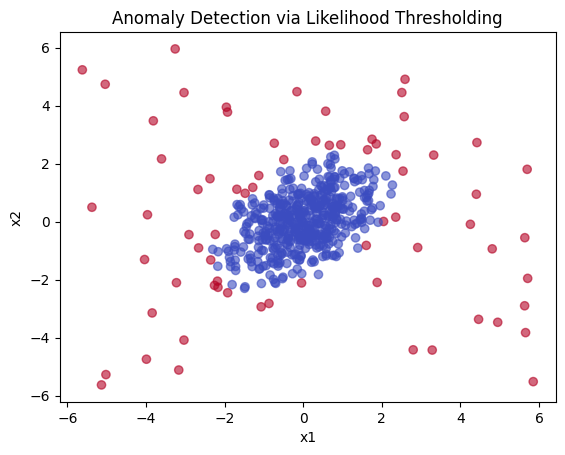

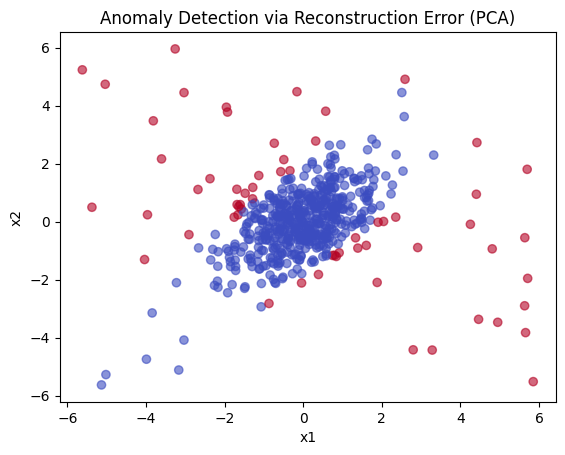

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal
from sklearn.decomposition import PCA


np.random.seed(42)

# Normal data (inliers)
n_normal = 500
mean = [0, 0]
cov = [[1, 0.5], [0.5, 1]]
X_normal = np.random.multivariate_normal(mean, cov, n_normal)

# Anomalies (outliers)
n_anomaly = 50
X_anomaly = np.random.uniform(low=-6, high=6, size=(n_anomaly, 2))

# Combined dataset
X = np.vstack([X_normal, X_anomaly])
y = np.array([0]*n_normal + [1]*n_anomaly)  # 0=normal, 1=anomaly


mean_hat = np.mean(X_normal, axis=0)
cov_hat = np.cov(X_normal, rowvar=False)

gaussian = multivariate_normal(mean=mean_hat, cov=cov_hat)


log_likelihoods = gaussian.logpdf(X)

threshold = np.percentile(
    gaussian.logpdf(X_normal), 5
)  # bottom 5%

y_pred_density = (log_likelihoods < threshold).astype(int)

plt.scatter(X[:,0], X[:,1], c=y_pred_density, cmap="coolwarm", alpha=0.6)
plt.title("Anomaly Detection via Likelihood Thresholding")
plt.xlabel("x1")
plt.ylabel("x2")
plt.show()

pca = PCA(n_components=1)
pca.fit(X_normal)


X_recon = pca.inverse_transform(pca.transform(X))
reconstruction_error = np.sum((X - X_recon)**2, axis=1)


threshold_pca = np.percentile(
    np.sum((X_normal - pca.inverse_transform(pca.transform(X_normal)))**2, axis=1),
    95
)

y_pred_pca = (reconstruction_error > threshold_pca).astype(int)


plt.scatter(X[:,0], X[:,1], c=y_pred_pca, cmap="coolwarm", alpha=0.6)
plt.title("Anomaly Detection via Reconstruction Error (PCA)")
plt.xlabel("x1")
plt.ylabel("x2")
plt.show()


### Probabilistic density models detect anomalies by identifying data points with low likelihood under the learned distribution, providing a principled statistical approach. Reconstruction-based methods, such as PCA, detect anomalies based on high reconstruction error, reflecting structural deviation from normal patterns. While likelihood-based methods offer stronger probabilistic interpretation, reconstruction-based approaches are more flexible when distributional assumptions are violated.